# Global Sensitivity C-revised — weighted class Diagnostics

Train-CV diagnostics only. Test·tuning·threshold 변경은 사용하지 않는다.


## 1. 입력과 25 Feature·weight 계약


In [1]:
import json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ROOT=Path(os.environ.get("KHUDA_PROJECT_ROOT",Path.cwd())).resolve()
while not (ROOT/"code").is_dir():
    if ROOT.parent==ROOT: raise RuntimeError("저장소 안에서 실행하세요.")
    ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
if "code" in sys.modules and not hasattr(sys.modules["code"],"__path__"): del sys.modules["code"]
from code.evaluation.evaluate import calculate_binary_metrics
from code.evaluation.sensitivity_diagnostics import cv_permutation_importance, normalize_oof_columns, paired_sampid_bootstrap_f1, subgroup_oof_metrics
from code.model.locked_sensitivity import load_stage_3_5_locked_params
from code.pipeline.audit import attach_person_period_column, calculate_train_sample_weight, load_selected_feature_names
from code.pipeline.saved_results import load_saved_global_train
RESULT_ROOT=ROOT/"data"/"result"/"baseline_42features"; STAGE35=RESULT_ROOT/"modeling"/"stage_3_5"
DATASET=RESULT_ROOT/"datasets"/"global_dataset.parquet"; SPLIT=RESULT_ROOT/"splits"/"split_ids.csv"; FEATURES=ROOT/"code"/"config"/"features.yaml"; MODELS=ROOT/"code"/"config"/"model_config.yaml"
SELECTED=RESULT_ROOT/"modeling"/"stage_3"/"selected_features.csv"; PARAMS=STAGE35/"final_refined_params.json"; A_SUMMARY=STAGE35/"final_tuning_summary.csv"; A_OOF={m:STAGE35/f"refined_{m}_oof_predictions.parquet" for m in ("logistic_regression","xgboost")}
LOCK=RESULT_ROOT/"modeling"/"sensitivity_sample_weight_weighted_class"; TUNE=LOCK/"tuning"; OUT=LOCK/"diagnostics"; LOCK_SUMMARY=LOCK/"locked_model_summary.csv"; LOCK_OOF={m:LOCK/f"locked_{m}_oof_predictions.parquet" for m in ("logistic_regression","xgboost")}; TUNE_OOF={m:TUNE/f"{m}_oof_predictions.parquet" for m in ("logistic_regression","xgboost")}
required=[DATASET,SPLIT,FEATURES,SELECTED,A_SUMMARY,*A_OOF.values(),LOCK_SUMMARY,*LOCK_OOF.values(),TUNE/"tuning_summary.csv",TUNE/"weighted_class_audit.csv",*TUNE_OOF.values()]; missing=[str(x) for x in required if not x.exists()]
if missing: raise FileNotFoundError("필요한 Train artifact가 없습니다:\n"+"\n".join(missing))
base=load_saved_global_train(DATASET,SPLIT,FEATURES); selected=load_selected_feature_names(SELECTED); weights=calculate_train_sample_weight(base.groups); row_count=base.groups.groupby(base.groups).transform("size")
assert len(selected)==25 and "n_prior_periods" not in base.X and weights.groupby(base.groups).sum().sub(1).abs().le(1e-12).all()


## 2. SAMPID row-count 분포·subgroup OOF


In [2]:
def oof(path): return normalize_oof_columns(pd.read_parquet(path))
def rows(strategy, summary, paths, status, stage=None):
    s=pd.read_csv(summary)
    if stage is not None: s=s.loc[s.stage.eq(stage)]
    s=s.set_index("model"); result=[]
    for model,path in paths.items():
        frame=oof(path); metric=calculate_binary_metrics(frame.y_true,frame.y_probability)
        result.append({"strategy":strategy,"model":model,"feature_count":int(s.loc[model,"feature_count"]),"parameter_status":status,"cv_f1_mean":s.loc[model,"cv_f1_mean"],"cv_f1_std":s.loc[model,"cv_f1_std"],"oof_accuracy":metric["accuracy"],"oof_precision":metric["precision"],"oof_recall":metric["recall"],"oof_f1":metric["f1"],"oof_roc_auc":metric["roc_auc"],"oof_average_precision":metric["average_precision"],"predicted_positive_rate":frame.y_predicted.mean()})
    return pd.DataFrame(result)
def paired(labels, frames):
    out=[]
    for label,left,right in labels:
        row=paired_sampid_bootstrap_f1(frames[left],frames[right]); row.insert(0,"comparison",label); out.append(row)
    return pd.concat(out,ignore_index=True)
row_distribution=pd.DataFrame({"SAMPID":base.groups,"row_count":row_count,"sample_weight":weights,"y":base.y}).groupby("row_count").agg(unique_SAMPID=("SAMPID","nunique"),person_period_rows=("SAMPID","size"),average_sample_weight=("sample_weight","mean"),sample_weight_total=("sample_weight","sum"),positive_count=("y","sum"),positive_rate=("y","mean")).reset_index()
row_distribution["person_ratio"]=row_distribution.unique_SAMPID/row_distribution.unique_SAMPID.sum(); row_distribution["row_ratio"]=row_distribution.person_period_rows/row_distribution.person_period_rows.sum(); display(row_distribution)
groups=[]
for strategy,paths in [("A Baseline",A_OOF),("C revised tuned",TUNE_OOF)]:
 for model,path in paths.items():
  x=subgroup_oof_metrics(oof(path),row_count,group_name="row_count"); x.insert(0,"model",model); x.insert(0,"strategy",strategy); groups.append(x)
row_group_metrics=pd.concat(groups,ignore_index=True); display(row_group_metrics)


,row_count,unique_SAMPID,person_period_rows,average_sample_weight,sample_weight_total,positive_count,positive_rate,person_ratio,row_ratio
0,1,1895,1895,1.000000,1895.0,1312,0.692348,0.330312,0.15891
1,2,1496,2992,0.500000,1496.0,1202,0.401738,0.260763,0.250901
2,3,2346,7038,0.333333,2346.0,602,0.085536,0.408925,0.590189


,strategy,model,row_count,rows,unique_SAMPID,positive_count,positive_rate,predicted_positive_rate,accuracy,precision,recall,f1,roc_auc,average_precision,confusion_matrix
0,A Baseline,logistic_regression,1,1895,1895,1312,0.692348,0.527704,0.635884,0.811000,0.618140,0.701557,0.699111,0.815257,"[[394, 189], [501, 811]]"
1,A Baseline,logistic_regression,2,2992,1496,1202,0.401738,0.427807,0.601604,0.503906,0.536606,0.519742,0.625007,0.508239,"[[1155, 635], [557, 645]]"
2,A Baseline,logistic_regression,3,7038,2346,602,0.085536,0.297812,0.727479,0.186069,0.647841,0.289103,0.759912,0.209475,"[[4730, 1706], [212, 390]]"
3,A Baseline,xgboost,1,1895,1895,1312,0.692348,0.585224,0.669129,0.808837,0.683689,0.741016,0.712498,0.820867,"[[371, 212], [415, 897]]"
4,A Baseline,xgboost,2,2992,1496,1202,0.401738,0.475267,0.605615,0.507736,0.600666,0.550305,0.633051,0.520295,"[[1090, 700], [480, 722]]"
5,A Baseline,xgboost,3,7038,2346,602,0.085536,0.344132,0.692526,0.177539,0.714286,0.284392,0.763452,0.209997,"[[4444, 1992], [172, 430]]"
6,C revised tuned,logistic_regression,1,1895,1895,1312,0.692348,0.541425,0.665435,0.830409,0.649390,0.728828,0.739848,0.846504,"[[409, 174], [460, 852]]"
7,C revised tuned,logistic_regression,2,2992,1496,1202,0.401738,0.425134,0.586898,0.486635,0.514975,0.500404,0.590248,0.478240,"[[1137, 653], [583, 619]]"
8,C revised tuned,logistic_regression,3,7038,2346,602,0.085536,0.259022,0.734157,0.151947,0.460133,0.228454,0.632461,0.132672,"[[4890, 1546], [325, 277]]"
9,C revised tuned,xgboost,1,1895,1895,1312,0.692348,0.608971,0.700264,0.822357,0.723323,0.769667,0.750790,0.852420,"[[378, 205], [363, 949]]"


## 3. weighted class correction audit


,fold,raw_pos,raw_neg,W_pos,W_neg,raw_neg_pos_ratio,weighted_neg_pos_ratio,class_weight_0,class_weight_1,model,scale_pos_weight
0,0,2493,7048,1697.833333,2911.166667,2.827116,1.714636,0.791607,1.357318,logistic_regression,NaN
1,1,2493,7048,1688.000000,2894.000000,2.827116,1.714455,0.791638,1.357227,logistic_regression,NaN
2,2,2493,7046,1688.666667,2892.333333,2.826314,1.712791,0.791921,1.356396,logistic_regression,NaN
3,3,2493,7046,1690.000000,2896.000000,2.826314,1.713609,0.791782,1.356805,logistic_regression,NaN
4,4,2492,7048,1690.166667,2899.833333,2.828250,1.715709,0.791425,1.357854,logistic_regression,NaN
5,0,2493,7048,1697.833333,2911.166667,2.827116,1.714636,NaN,NaN,xgboost,1.714636
6,1,2493,7048,1688.000000,2894.000000,2.827116,1.714455,NaN,NaN,xgboost,1.714455
7,2,2493,7046,1688.666667,2892.333333,2.826314,1.712791,NaN,NaN,xgboost,1.712791
8,3,2493,7046,1690.000000,2896.000000,2.826314,1.713609,NaN,NaN,xgboost,1.713609
9,4,2492,7048,1690.166667,2899.833333,2.828250,1.715709,NaN,NaN,xgboost,1.715709


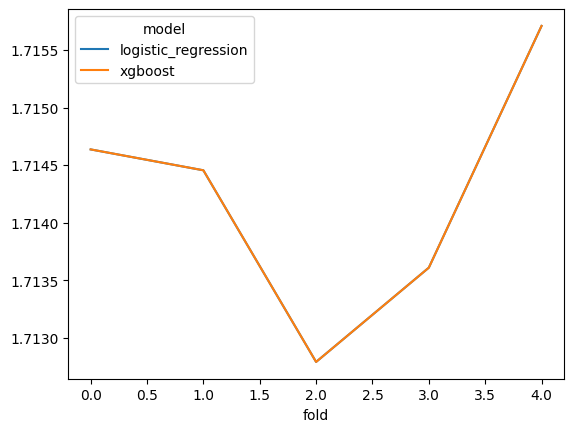

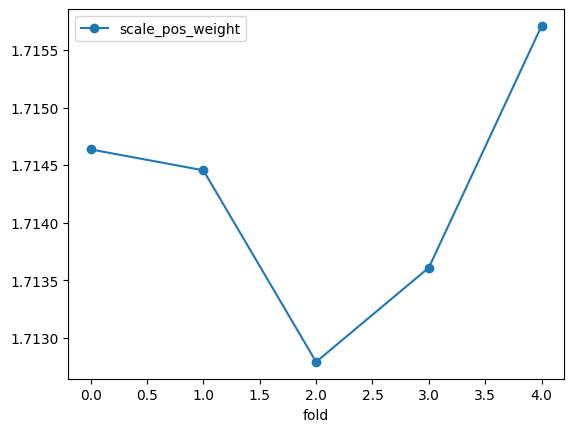

In [3]:
weighted_audit=pd.read_csv(TUNE/"weighted_class_audit.csv"); display(weighted_audit)
fig,ax=plt.subplots(); weighted_audit.pivot(index="fold",columns="model",values="weighted_neg_pos_ratio").plot(ax=ax); plt.show()
fig,ax=plt.subplots(); weighted_audit.query("model=='xgboost'").plot(x="fold",y="scale_pos_weight",marker="o",ax=ax); plt.show()


## 4. A / C locked / C tuned stability


In [4]:
def oof(path): return normalize_oof_columns(pd.read_parquet(path))
def rows(strategy, summary, paths, status, stage=None):
    s=pd.read_csv(summary)
    if stage is not None: s=s.loc[s.stage.eq(stage)]
    s=s.set_index("model"); result=[]
    for model,path in paths.items():
        frame=oof(path); metric=calculate_binary_metrics(frame.y_true,frame.y_probability)
        result.append({"strategy":strategy,"model":model,"feature_count":int(s.loc[model,"feature_count"]),"parameter_status":status,"cv_f1_mean":s.loc[model,"cv_f1_mean"],"cv_f1_std":s.loc[model,"cv_f1_std"],"oof_accuracy":metric["accuracy"],"oof_precision":metric["precision"],"oof_recall":metric["recall"],"oof_f1":metric["f1"],"oof_roc_auc":metric["roc_auc"],"oof_average_precision":metric["average_precision"],"predicted_positive_rate":frame.y_predicted.mean()})
    return pd.DataFrame(result)
def paired(labels, frames):
    out=[]
    for label,left,right in labels:
        row=paired_sampid_bootstrap_f1(frames[left],frames[right]); row.insert(0,"comparison",label); out.append(row)
    return pd.concat(out,ignore_index=True)
tuned=pd.read_csv(TUNE/"tuning_summary.csv"); tuned["strategy"]="C revised tuned"; tuned["parameter_status"]="tuned"; a=rows("A Baseline",A_SUMMARY,A_OOF,"locked",stage="stage_3_5"); locked=rows("C revised locked",LOCK_SUMMARY,LOCK_OOF,"locked"); comparison=pd.concat([a,locked,tuned],ignore_index=True)
base_f1=comparison.query("strategy=='A Baseline'").set_index("model").oof_f1; locked_f1=comparison.query("strategy=='C revised locked'").set_index("model").oof_f1; comparison["delta_oof_f1_vs_A"]=comparison.apply(lambda r:r.oof_f1-base_f1[r.model],axis=1); comparison["locked_to_tuned_delta_f1"]=comparison.apply(lambda r:r.oof_f1-locked_f1[r.model],axis=1); display(comparison)
frames={"A "+m:oof(A_OOF[m]) for m in A_OOF}|{"C locked "+m:oof(LOCK_OOF[m]) for m in LOCK_OOF}|{"C tuned "+m:oof(TUNE_OOF[m]) for m in TUNE_OOF}; bootstrap=pd.concat([paired([("C locked - A","C locked "+m,"A "+m),("C tuned - A","C tuned "+m,"A "+m),("C tuned - C locked","C tuned "+m,"C locked "+m)],frames).assign(model=m) for m in ("logistic_regression","xgboost")],ignore_index=True); display(bootstrap)


,strategy,model,feature_count,parameter_status,cv_f1_mean,cv_f1_std,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,best_cv_f1,best_params,delta_oof_f1_vs_A,locked_to_tuned_delta_f1
0,A Baseline,logistic_regression,25,locked,0.493122,0.022909,0.681342,0.421846,0.592426,0.492792,0.702235,0.430911,0.366960,NaN,NaN,0.000000,0.010891
1,A Baseline,xgboost,25,locked,0.507894,0.016047,0.667002,0.413689,0.657574,0.507870,0.710534,0.441191,0.415346,NaN,NaN,0.000000,0.013734
2,C revised locked,logistic_regression,25,locked,0.481941,0.020577,0.685535,0.423096,0.559692,0.481901,0.691217,0.424212,0.345660,NaN,NaN,-0.010891,0.000000
3,C revised locked,xgboost,25,locked,0.494076,0.023327,0.667254,0.409898,0.621951,0.494136,0.702235,0.430521,0.396478,NaN,NaN,-0.013734,0.000000
4,C revised tuned,logistic_regression,25,tuned,0.483073,0.021540,0.686289,0.424169,0.560976,0.483073,0.691567,0.425611,0.345577,0.483073,"{'class_weight': 'weighted_class_balanced', 'C...",-0.009719,0.001172
5,C revised tuned,xgboost,25,tuned,0.496699,0.020988,0.667505,0.410875,0.628049,0.496764,0.704397,0.434656,0.399413,0.496699,{'scale_pos_weight': 'train_weighted_negative_...,-0.011106,0.002628


,comparison,point_delta_f1,bootstrap_mean_delta,ci_lower,ci_upper,bootstrap_repeats,model
0,C locked - A,-0.010891,-0.011068,-0.018218,-0.003735,1000,logistic_regression
1,C tuned - A,-0.009719,-0.009869,-0.017132,-0.002576,1000,logistic_regression
2,C tuned - C locked,0.001172,0.001198,-0.001469,0.003945,1000,logistic_regression
3,C locked - A,-0.013734,-0.013621,-0.020934,-0.006708,1000,xgboost
4,C tuned - A,-0.011106,-0.011017,-0.018419,-0.003696,1000,xgboost
5,C tuned - C locked,0.002628,0.002604,-0.001454,0.006556,1000,xgboost


## 5. 저장·최종 진단 표


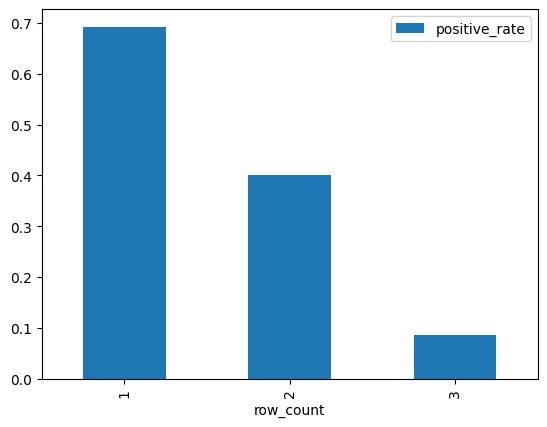

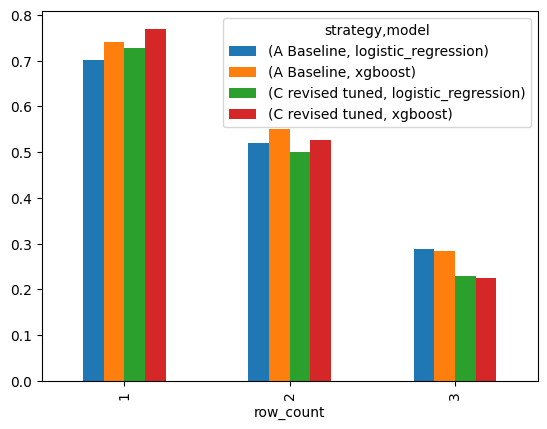

,strategy,model,feature_count,parameter_status,cv_f1_mean,cv_f1_std,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,best_cv_f1,best_params,delta_oof_f1_vs_A,locked_to_tuned_delta_f1
0,A Baseline,logistic_regression,25,locked,0.493122,0.022909,0.681342,0.421846,0.592426,0.492792,0.702235,0.430911,0.366960,NaN,NaN,0.000000,0.010891
1,A Baseline,xgboost,25,locked,0.507894,0.016047,0.667002,0.413689,0.657574,0.507870,0.710534,0.441191,0.415346,NaN,NaN,0.000000,0.013734
2,C revised locked,logistic_regression,25,locked,0.481941,0.020577,0.685535,0.423096,0.559692,0.481901,0.691217,0.424212,0.345660,NaN,NaN,-0.010891,0.000000
3,C revised locked,xgboost,25,locked,0.494076,0.023327,0.667254,0.409898,0.621951,0.494136,0.702235,0.430521,0.396478,NaN,NaN,-0.013734,0.000000
4,C revised tuned,logistic_regression,25,tuned,0.483073,0.021540,0.686289,0.424169,0.560976,0.483073,0.691567,0.425611,0.345577,0.483073,"{'class_weight': 'weighted_class_balanced', 'C...",-0.009719,0.001172
5,C revised tuned,xgboost,25,tuned,0.496699,0.020988,0.667505,0.410875,0.628049,0.496764,0.704397,0.434656,0.399413,0.496699,{'scale_pos_weight': 'train_weighted_negative_...,-0.011106,0.002628


,row_count,unique_SAMPID,person_period_rows,average_sample_weight,sample_weight_total,positive_count,positive_rate,person_ratio,row_ratio
0,1,1895,1895,1.000000,1895.0,1312,0.692348,0.330312,0.15891
1,2,1496,2992,0.500000,1496.0,1202,0.401738,0.260763,0.250901
2,3,2346,7038,0.333333,2346.0,602,0.085536,0.408925,0.590189


,comparison,point_delta_f1,bootstrap_mean_delta,ci_lower,ci_upper,bootstrap_repeats,model
0,C locked - A,-0.010891,-0.011068,-0.018218,-0.003735,1000,logistic_regression
1,C tuned - A,-0.009719,-0.009869,-0.017132,-0.002576,1000,logistic_regression
2,C tuned - C locked,0.001172,0.001198,-0.001469,0.003945,1000,logistic_regression
3,C locked - A,-0.013734,-0.013621,-0.020934,-0.006708,1000,xgboost
4,C tuned - A,-0.011106,-0.011017,-0.018419,-0.003696,1000,xgboost
5,C tuned - C locked,0.002628,0.002604,-0.001454,0.006556,1000,xgboost


In [5]:
OUT.mkdir(parents=True,exist_ok=True); comparison.to_csv(OUT/"diagnostics_summary.csv",index=False); row_distribution.to_csv(OUT/"sampid_row_count_distribution.csv",index=False); row_group_metrics.to_csv(OUT/"row_count_group_metrics.csv",index=False); weighted_audit.to_csv(OUT/"weighted_class_audit_summary.csv",index=False); bootstrap.to_csv(OUT/"paired_bootstrap_oof.csv",index=False)
fold=pd.read_json(TUNE/"fold_f1.json").melt(var_name="model",value_name="f1").rename_axis("fold").reset_index(); fold.to_csv(OUT/"fold_comparison.csv",index=False)
fig,ax=plt.subplots(); row_distribution.plot.bar(x="row_count",y="positive_rate",ax=ax); plt.show(); fig,ax=plt.subplots(); row_group_metrics.pivot_table(index="row_count",columns=["strategy","model"],values="f1").plot.bar(ax=ax); plt.show(); display(comparison); display(row_distribution); display(bootstrap)
